# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("unit2_ppt5_country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

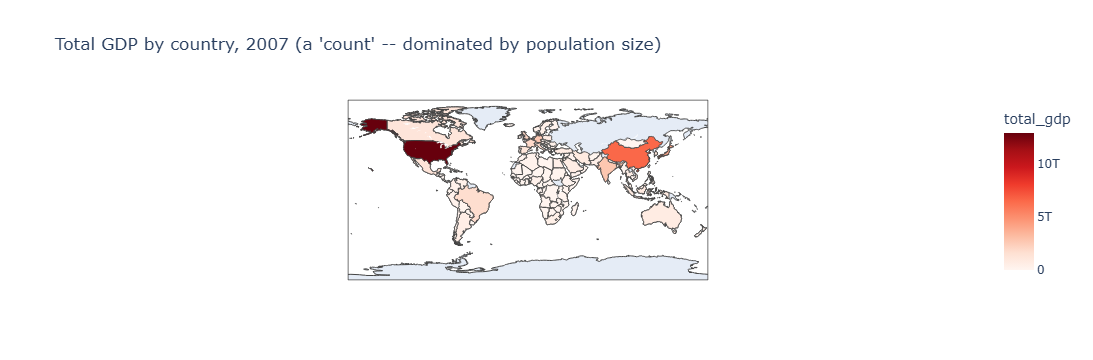

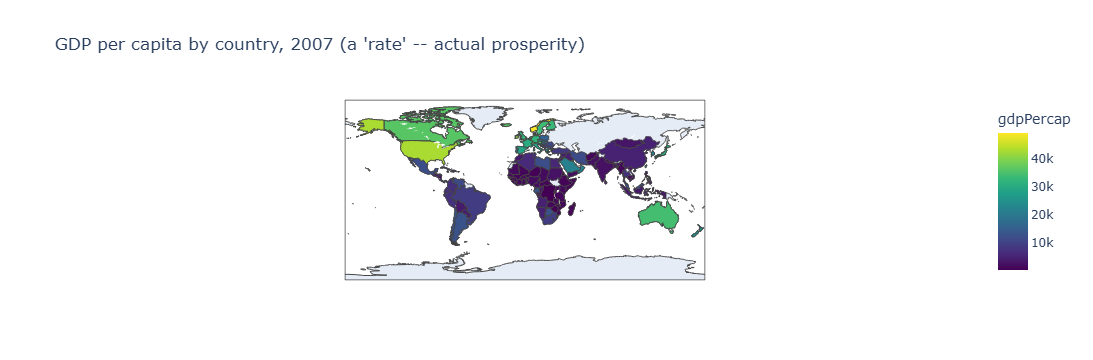

Top 5 by total GDP:
            country     total_gdp     gdpPercap
134  United States  1.293446e+13  42951.653090
24           China  6.539501e+12   4959.114854
66           Japan  4.035135e+12  31656.068060
58           India  2.722925e+12   2452.210407
47         Germany  2.650871e+12  32170.374420

Top 5 by GDP per capita:
            country     total_gdp    gdpPercap
95          Norway  2.284214e+11  49357.19017
71          Kuwait  1.185305e+11  47306.98978
113      Singapore  2.146433e+11  47143.17964
134  United States  1.293446e+13  42951.65309
62         Ireland  1.671412e+11  40675.99635


In [7]:
# TODO 1: choropleth of total_gdp
fig1 = px.choropleth(gap_latest, locations="iso_alpha", color="total_gdp",
                      hover_name="country", color_continuous_scale="Reds",
                      title="Total GDP by country, 2007 (a 'count' -- dominated by population size)")
fig1.show()

# TODO 2: choropleth of gdpPercap
fig2 = px.choropleth(gap_latest, locations="iso_alpha", color="gdpPercap",
                      hover_name="country", color_continuous_scale="Viridis",
                      title="GDP per capita by country, 2007 (a 'rate' -- actual prosperity)")
fig2.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp", "gdpPercap"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "total_gdp", "gdpPercap"]]
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?
 
_Your answer:_ The two lists barely overlap. Total GDP top 5 is United States, China, Japan, India, Germany -- essentially a ranking of the world's biggest populations. GDP per capita top 5 is Norway, Kuwait, Singapore, United States, Ireland -- small, wealthy economies that total GDP would never surface (China, India, Japan, and Germany drop out entirely, replaced by Norway, Kuwait, Singapore, and Ireland). The United States is the only country that appears on both lists.

I'd show the director the GDP-per-capita (rate) map. Total GDP is really a population map in disguise -- it rewards a country for having more people, not for being more prosperous, which is exactly the "Greenland vs. India" trap the director complained about. GDP per capita answers the question the director actually cares about: how well-off is a typical person in that country.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

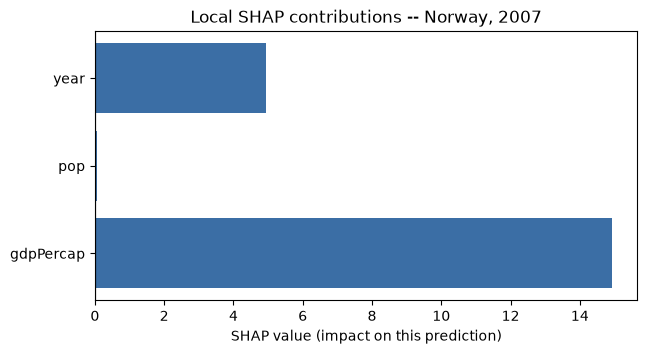

In [8]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder[(gapminder.country == "Norway") & (gapminder.year == 2007)].index[0]
vals = shap_values[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))
# plot vals as a diverging horizontal bar chart here
colors = ["#3b6ea5" if v >= 0 else "#b5432e" for v in vals]
ax.barh(["gdpPercap", "pop", "year"], vals, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("SHAP value (impact on this prediction)")
ax.set_title("Local SHAP contributions -- Norway, 2007")
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_ For Norway in 2007 the SHAP values are gdpPercap = +14.92, year = +4.93, and pop = +0.05. gdpPercap is by far the largest positive contributor, pushing the prediction up nearly 15 years above the model's base rate; year adds a smaller positive push (later years generally have higher predicted life expectancy); pop is essentially neutral for this row (Norway's population isn't unusual enough to move the prediction much). None of the three features pushes the prediction down for Norway.

This lines up with the ranking from global feature importance (gdpPercap is the most important feature overall), but global importance alone couldn't have told us the direction and size of the effect for Norway specifically -- it only says "gdpPercap matters a lot across all countries," not "gdpPercap added about 15 years to Norway's prediction while population was basically irrelevant here." That's exactly the gap local SHAP values fill.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

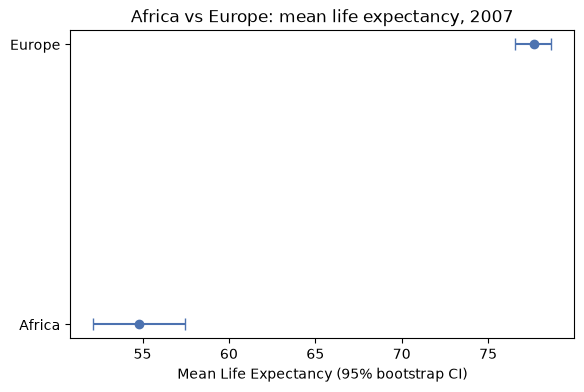

Africa: mean=54.81, 95% CI=[52.15, 57.44], n=52, sd=9.63
Europe: mean=77.65, 95% CI=[76.57, 78.65], n=30, sd=2.98


In [10]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    boot_means = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
    return np.mean(values), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"  # feel free to change these
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
means = [result_a[0], result_b[0]]
los = [result_a[0] - result_a[1], result_b[0] - result_b[1]]
his = [result_a[2] - result_a[0], result_b[2] - result_b[0]]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.errorbar(means, [continent_a, continent_b], xerr=[los, his], fmt="o", color="#4C72B0", capsize=4)
ax.set_xlabel("Mean Life Expectancy (95% bootstrap CI)")
ax.set_title(f"{continent_a} vs {continent_b}: mean life expectancy, 2007")
plt.show()

print(f"{continent_a}: mean={result_a[0]:.2f}, 95% CI=[{result_a[1]:.2f}, {result_a[2]:.2f}], n={len(values_a)}, sd={values_a.std(ddof=1):.2f}")
print(f"{continent_b}: mean={result_b[0]:.2f}, 95% CI=[{result_b[1]:.2f}, {result_b[2]:.2f}], n={len(values_b)}, sd={values_b.std(ddof=1):.2f}")

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_ Africa has the wider interval: [52.15, 57.44] (a span of about 5.3 years) versus Europe's [76.57, 78.65] (a span of about 2.1 years).

It's mostly higher variation (SD), not sample size. Africa's country-level SD is about 9.6 years vs. Europe's 3.0 years -- roughly 3x more spread in life expectancy across African countries. If anything, sample size works against Africa having the wider interval: Africa has more countries in the sample (n=52) than Europe (n=30), which should narrow its CI, not widen it. Since Africa's interval is still much wider despite the larger n, the SD difference is doing all the work.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

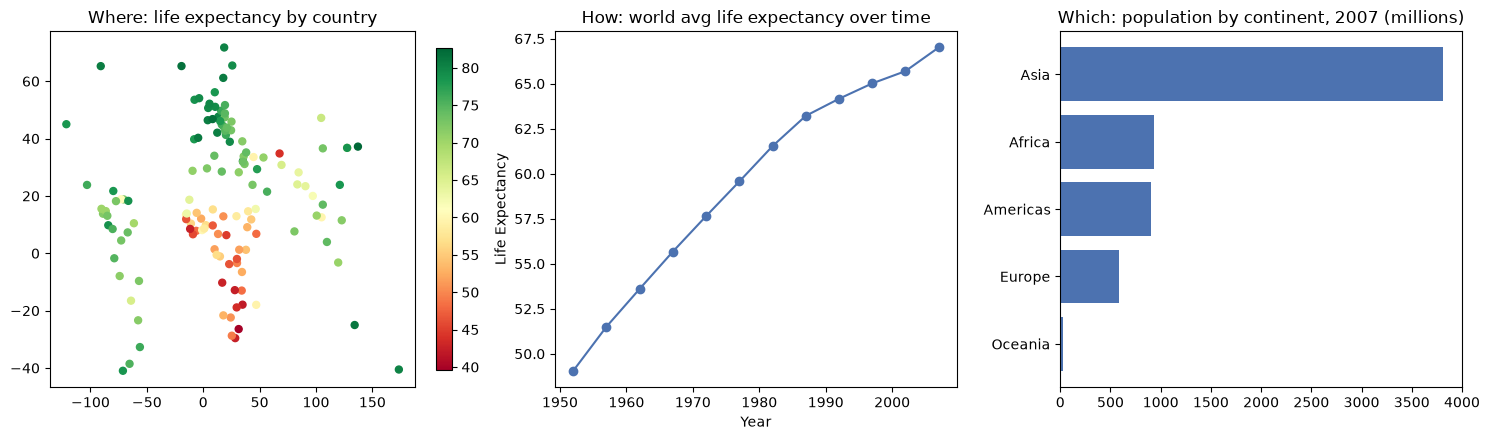

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
d = gap_latest.dropna(subset=["centroid_lat"])
sc = axes[0].scatter(d.centroid_lon, d.centroid_lat, c=d.lifeExp, cmap="RdYlGn", s=25)
axes[0].set_title("Where: life expectancy by country")
plt.colorbar(sc, ax=axes[0], fraction=0.04)

# TODO 2: world trend line (axes[1])
world_trend = gapminder.groupby("year", as_index=False)["lifeExp"].mean()
axes[1].plot(world_trend.year, world_trend.lifeExp, "o-", color="#4C72B0")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Life Expectancy")
axes[1].set_title("How: world avg life expectancy over time")

# TODO 3: population by continent bar chart (axes[2])
cont_pop = gap_latest.groupby("continent")["pop"].sum().sort_values()
axes[2].barh(cont_pop.index, cont_pop.values / 1e6, color="#4C72B0")
axes[2].set_title("Which: population by continent, 2007 (millions)")

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_ I'd keep the world trend line (middle panel). A single glance at it immediately answers "is the thing we track getting better or worse over time, and how fast" -- the core "trend" monitoring question. The map panel is better for spotting where an exception is happening, and the population bar chart is better for a ranking question, but neither tells the director in one glance whether global progress is accelerating, stalling, or reversing, which is the thing a policymaker briefing needs to open with. The map and bar chart are still useful as drill-down views once the trend flags something worth investigating.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_ I recommend we standardize on rate-based (per-capita) choropleths, not raw-count maps, for every future report -- Task 1 showed that a total-GDP map is really a population map in disguise, and it produces a completely different "top 5" than the per-capita map, which is exactly the kind of misleading impression that burned us before. When a journalist asks why the model predicted a specific number for one country, we should lead with local SHAP values for that country, not the model's global feature importance -- global importance only tells us which feature matters most on average across all countries, while local importance gave us Norway's exact, signed, per-feature contribution, which is the only thing that actually answers a "why THIS country" question. Finally, our continental life-expectancy averages (and any other survey-style estimate, such as the world trend line) should never be shown as a bare point estimate -- Task 3 showed that Africa's estimate carries roughly twice the uncertainty of Europe's because of higher country-to-country variation, and presenting either as a single confident number would hide that difference in reliability from the director and from readers of the report.